In [1]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# Load the data saved in last unit
df = pd.read_csv('data/cleaned_customers.csv')
df.head()

,CustomerID,Signup_Date,Last_purchase_date,email,Phone_number,Gender_encoded,Country_encoded,Age_scaled,Purchase_scaled,Feedback_scaled
0,NaN,31/12/2024,13/08/2025,unknown@missing.com,0,0.0,1,-0.435539,-0.764246,-0.434743
1,C2,NaN,NaN,user1mail.com,abc123,NaN,1,-0.344951,NaN,-1.084230
2,3,NaN,20/06/2023,user2@mail.com,abc123,NaN,2,-0.047305,NaN,1.297222
3,C4,NaN,13/09/2025,unknown@missing.com,9316267914,NaN,4,-0.332010,NaN,NaN
4,5,09/07/2025,NaN,user4mail.com,9234603292,NaN,4,1.686808,-0.764246,NaN


In [4]:
# we use the same features as Isolation Forest for fair comparision
feature_columns = [
    'Age_scaled', 
    'Purchase_scaled', 
    'Feedback_scaled', 
    'Gender_encoded', 
    'Country_encoded'
]

x = df[feature_columns].values
identifiers = df[['CustomerID', 'email', 'Phone_number']].copy()

In [5]:
# ============================================
# CELL 1: Fixing the NaN values in the features
# ============================================

print(" Fixing NaN values in features...")

# Check which columns have NaNs
nan_cols = df[feature_columns].isna().sum()
print("Columns with NaNs:")
print(nan_cols[nan_cols > 0])

# 1. Fill numeric columns with MEDIAN
numeric_cols = ['Age_scaled', 'Purchase_scaled', 'Feedback_scaled']
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f" Fixed {col}: filled with median {median_val:.4f}")

# 2. Fill categorical columns with MODE (most common value)
categorical_cols = ['Gender_encoded', 'Country_encoded']
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f" Fixed {col}: filled with mode {mode_val}")

# Verify
nan_count_after = df[feature_columns].isna().sum().sum()
print(f"\n Total NaNs remaining in features: {nan_count_after}")

# Save the fixed data
df.to_csv('data/cleaned_customers_fixed.csv', index=False)
print(" Clean data saved to 'data/cleaned_customers_fixed.csv'")

 Fixing NaN values in features...
Columns with NaNs:
Purchase_scaled    5033
Feedback_scaled    2462
Gender_encoded     7489
dtype: int64
 Fixed Age_scaled: filled with median -0.3450
 Fixed Purchase_scaled: filled with median -0.7642
 Fixed Feedback_scaled: filled with median -0.2182
 Fixed Gender_encoded: filled with mode 0.0
 Fixed Country_encoded: filled with mode -1

 Total NaNs remaining in features: 0
 Clean data saved to 'data/cleaned_customers_fixed.csv'


In [8]:
# ============================================
# Define the Autoencoder class
# ============================================

import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=2):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, encoding_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 4),
            nn.ReLU(),
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

print(" Autoencoder class defined.")

 Autoencoder class defined.


In [9]:
# ============================================
# CELL 2: Retrain the Autoencoder on clean data
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

# 1. Prepare the clean data
X = df[feature_columns].values
X_tensor = torch.tensor(X, dtype=torch.float32)
dataset = torch.utils.data.TensorDataset(X_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

# 2. Re-define the model (fresh start)
input_dim = X.shape[1]
model = Autoencoder(input_dim, encoding_dim=2)

# 3. Lower learning rate + gradient clipping for stability
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# 4. Train for 20 epochs (quick and stable)
print(" Retraining Autoencoder on clean data...")
loss_history = []

for epoch in range(20):
    epoch_loss = 0.0
    for batch in dataloader:
        inputs = batch[0]
        
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Prevent exploding gradients
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/20 - Loss: {avg_loss:.6f}")

print(" Model retrained successfully!")

 Retraining Autoencoder on clean data...
Epoch 5/20 - Loss: 1.106869
Epoch 10/20 - Loss: 1.092482
Epoch 15/20 - Loss: 1.090810
Epoch 20/20 - Loss: 1.089841
 Model retrained successfully!


"I built a symmetrical Autoencoder with a 2-dimensional bottleneck. The Encoder compresses the 5 input features down to 2 using a sequence of Linear layers and ReLU activations. The Decoder then expands the 2 numbers back to 5. By forcing the data through this tiny bottleneck, the model learns the core patterns of a 'normal' customer. When I pass a corrupted customer through, the Decoder fails to reconstruct them, resulting in a high Mean Squared Error—which flags them as an anomaly."

In [14]:
# ============================================
# Cell 3: Recalculate Reconstruction Errors
# ============================================

model.eval()

with torch.no_grad():
    X_tensor_full = torch.tensor(df[feature_columns].values, dtype=torch.float32)
    reconstructions = model(X_tensor_full)
    new_errors = torch.mean((reconstructions - X_tensor_full) ** 2, dim=1).numpy()

# Add the clean errors to the dataframe
df['AE_Reconstruction_Error'] = new_errors

# Verify
nan_count = df['AE_Reconstruction_Error'].isna().sum()
print(f" NaN count in reconstruction errors: {nan_count}")
print(f" Sample errors: {df['AE_Reconstruction_Error'].head(10)}")
print(f" Min: {df['AE_Reconstruction_Error'].min():.6f}")
print(f" Max: {df['AE_Reconstruction_Error'].max():.6f}")

 NaN count in reconstruction errors: 0
 Sample errors: 0    0.147382
1    0.317495
2    0.446298
3    1.312911
4    1.863559
5    0.499210
6    1.056754
7    1.016332
8    0.319196
9    0.445854
Name: AE_Reconstruction_Error, dtype: float32
 Min: 0.061697
 Max: 3.549662


 Total Customers: 10000
 Normal (Blue): 9564
 Anomalies (Red): 436
 Threshold: 2.212930


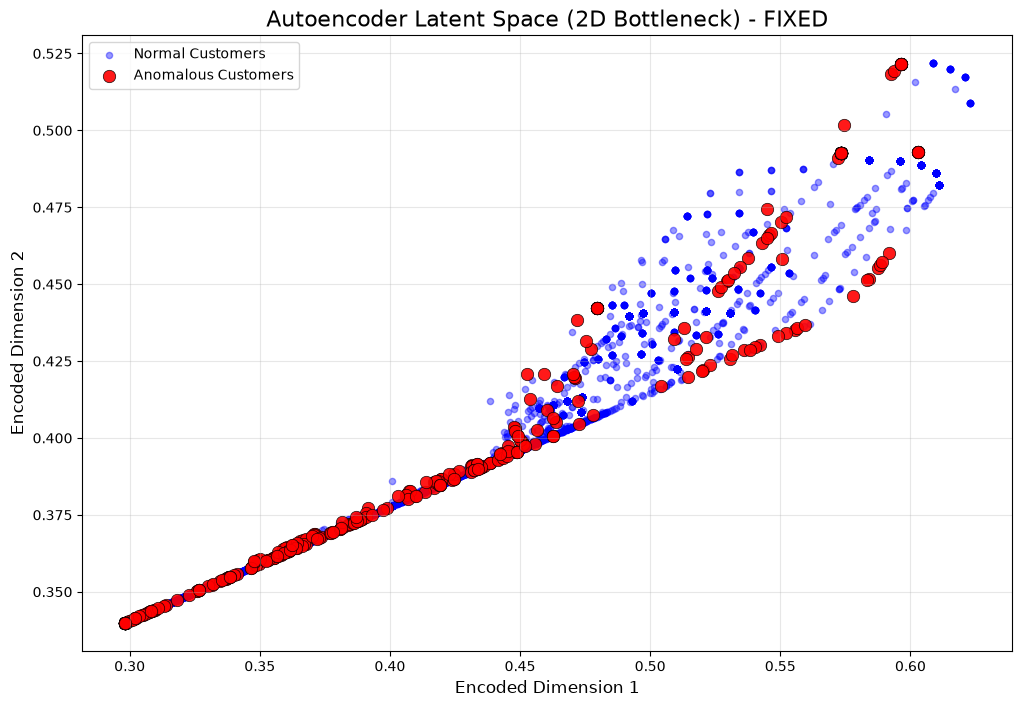

 Plot saved as 'latent_space_fixed.png' in your project folder.


In [15]:
# ============================================
# Cell 4: Plot the Latent Space
# ============================================

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Calculate threshold (Top 5%)
threshold = np.percentile(df['AE_Reconstruction_Error'], 95)

# Split data
anomalies = df[df['AE_Reconstruction_Error'] > threshold]
normals = df[df['AE_Reconstruction_Error'] <= threshold]

print(f" Total Customers: {len(df)}")
print(f" Normal (Blue): {len(normals)}")
print(f" Anomalies (Red): {len(anomalies)}")
print(f" Threshold: {threshold:.6f}")

# Create plot
fig, ax = plt.subplots(figsize=(12, 8))

if len(normals) > 0:
    ax.scatter(normals['Encoded_X'], normals['Encoded_Y'], 
               c='blue', alpha=0.4, s=20, label='Normal Customers')

if len(anomalies) > 0:
    ax.scatter(anomalies['Encoded_X'], anomalies['Encoded_Y'], 
               c='red', alpha=0.9, s=80, edgecolors='black', linewidth=0.5,
               label='Anomalous Customers')

ax.set_title('Autoencoder Latent Space (2D Bottleneck) - FIXED', fontsize=16)
ax.set_xlabel('Encoded Dimension 1', fontsize=12)
ax.set_ylabel('Encoded Dimension 2', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()
fig.savefig('latent_space_fixed.png', dpi=300, bbox_inches='tight')
print(" Plot saved as 'latent_space_fixed.png' in your project folder.")

In [16]:
# ============================================
# Cell 1: Fetch the latest GX report from Neon
# ============================================

import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

# Fetch the most recent validation report
query = """
SELECT 
    report_id,
    run_timestamp,
    total_expectations,
    passed_expectations,
    failed_expectations,
    success_rate,
    data_trust_score
FROM validation_reports
ORDER BY run_timestamp DESC
LIMIT 1
"""

gx_report = pd.read_sql(query, engine)

print("📊 LATEST GREAT EXPECTATIONS REPORT")
print("=" * 60)
print(f"Report ID: {gx_report['report_id'].iloc[0]}")
print(f"Timestamp: {gx_report['run_timestamp'].iloc[0]}")
print(f"Total Expectations: {gx_report['total_expectations'].iloc[0]}")
print(f"Passed: {gx_report['passed_expectations'].iloc[0]}")
print(f"Failed: {gx_report['failed_expectations'].iloc[0]}")
print(f"GX Data Trust Score: {gx_report['data_trust_score'].iloc[0]}%")

📊 LATEST GREAT EXPECTATIONS REPORT
Report ID: 2
Timestamp: 2026-08-09 07:13:02.938601
Total Expectations: 5
Passed: 1
Failed: 4
GX Data Trust Score: 20.0%


In [18]:
# ============================================
# Quick Fix: Re-add Isolation Forest scores
# ============================================

from sklearn.ensemble import IsolationForest

# 1. Define features (same as before)
feature_columns = ['Age_scaled', 'Purchase_scaled', 'Feedback_scaled', 'Gender_encoded', 'Country_encoded']
X_if = df[feature_columns].values

# 2. Train Isolation Forest (same parameters as Unit 3.2)
iso_model = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
iso_model.fit(X_if)

# 3. Add predictions and scores
df['IF_Prediction'] = iso_model.predict(X_if)
df['IF_Anomaly_Score'] = iso_model.decision_function(X_if)

print("✅ Isolation Forest columns added to the current dataframe!")
print(f"   IF_Anomalies: {(df['IF_Prediction'] == -1).sum()}")
print(f"   IF_Normals: {(df['IF_Prediction'] == 1).sum()}")

✅ Isolation Forest columns added to the current dataframe!
   IF_Anomalies: 1000
   IF_Normals: 9000


In [19]:
# ============================================
# Cell 2: Calculate ML Anomaly Rates
# ============================================

# 1. Isolation Forest Anomalies (IF_Prediction == -1)
if_anomalies = (df['IF_Prediction'] == -1).sum()
if_total = len(df)
if_anomaly_rate = (if_anomalies / if_total) * 100

# 2. Autoencoder Anomalies (Top 5% reconstruction error)
ae_threshold = np.percentile(df['AE_Reconstruction_Error'], 95)
ae_anomalies = (df['AE_Reconstruction_Error'] > ae_threshold).sum()
ae_total = len(df)
ae_anomaly_rate = (ae_anomalies / ae_total) * 100

# 3. Overlap between IF and AE (customers flagged by BOTH)
both_anomalies = df[(df['IF_Prediction'] == -1) & (df['AE_Reconstruction_Error'] > ae_threshold)]
both_anomalies_count = len(both_anomalies)
overlap_rate = (both_anomalies_count / if_total) * 100

print("📊 ML ANOMALY DETECTION SUMMARY")
print("=" * 60)
print(f"🔍 Isolation Forest Anomalies: {if_anomalies} / {if_total} ({if_anomaly_rate:.2f}%)")
print(f"🧠 Autoencoder Anomalies: {ae_anomalies} / {ae_total} ({ae_anomaly_rate:.2f}%)")
print(f"🔄 Overlap (Both Models Agree): {both_anomalies_count} / {if_total} ({overlap_rate:.2f}%)")

📊 ML ANOMALY DETECTION SUMMARY
🔍 Isolation Forest Anomalies: 1000 / 10000 (10.00%)
🧠 Autoencoder Anomalies: 436 / 10000 (4.36%)
🔄 Overlap (Both Models Agree): 332 / 10000 (3.32%)


In [20]:
# ============================================
# Cell 3: Calculate the AI-Powered Data Trust Score
# ============================================

# 1. Get the GX base score
gx_score = gx_report['data_trust_score'].iloc[0]  # 20%

# 2. Define penalties
# GX Penalty: If only 1 out of 5 rules passed, the penalty is proportional.
# Failed rules = 4 out of 5.
gx_failure_penalty = (1 - gx_score / 100) * 30  # Max 30% penalty
print(f"📉 GX Penalty: {gx_failure_penalty:.2f}%")

# IF Penalty: If IF_anomaly_rate is high, apply a penalty.
# Max 20% penalty if IF_anomaly_rate is > 10%.
if_penalty = min(if_anomaly_rate * 2, 20)  # Capped at 20%
print(f"📉 IF Penalty: {if_penalty:.2f}%")

# AE Penalty: If AE_anomaly_rate is high, apply a penalty.
# Max 20% penalty if AE_anomaly_rate is > 5%.
ae_penalty = min(ae_anomaly_rate * 4, 20)  # Capped at 20%
print(f"📉 AE Penalty: {ae_penalty:.2f}%")

# 3. Calculate the final score
# Start at 100%, subtract all penalties
final_score = 100 - gx_failure_penalty - if_penalty - ae_penalty

# Ensure the score stays between 0 and 100
final_score = max(0, min(100, final_score))

print("\n" + "=" * 60)
print("🎯 FINAL AI-POWERED DATA TRUST SCORE")
print("=" * 60)
print(f"✅ Starting Score: 100%")
print(f"📉 GX Penalty: -{gx_failure_penalty:.2f}%")
print(f"📉 IF Penalty: -{if_penalty:.2f}%")
print(f"📉 AE Penalty: -{ae_penalty:.2f}%")
print(f"⭐ Final Data Trust Score: {final_score:.2f}%")

📉 GX Penalty: 24.00%
📉 IF Penalty: 20.00%
📉 AE Penalty: 17.44%

🎯 FINAL AI-POWERED DATA TRUST SCORE
✅ Starting Score: 100%
📉 GX Penalty: -24.00%
📉 IF Penalty: -20.00%
📉 AE Penalty: -17.44%
⭐ Final Data Trust Score: 38.56%


In [22]:
# ============================================
# Cell 4: Save the New Score to Neon (FIXED)
# ============================================

from datetime import datetime, timezone
from sqlalchemy import text

# Ensure values are native Python types, not NumPy types
gx_score_value = float(gx_score)  # Convert np.float64 to float
final_score_value = float(final_score)  # Convert np.float64 to float

# Prepare the data to insert
new_report = {
    "run_timestamp": datetime.now(timezone.utc),
    "total_expectations": int(gx_report['total_expectations'].iloc[0]),
    "passed_expectations": int(gx_report['passed_expectations'].iloc[0]),
    "failed_expectations": int(gx_report['failed_expectations'].iloc[0]),
    "success_rate": gx_score_value,
    "data_trust_score": final_score_value,
    "validation_results": f'{{"isolation_forest": {if_anomaly_rate:.2f}, "autoencoder": {ae_anomaly_rate:.2f}, "gx": {gx_score_value}}}'
}

# Insert into the database
with engine.connect() as conn:
    insert_query = text("""
        INSERT INTO validation_reports (
            run_timestamp,
            total_expectations,
            passed_expectations,
            failed_expectations,
            success_rate,
            data_trust_score,
            validation_results
        ) VALUES (
            :run_timestamp,
            :total_expectations,
            :passed_expectations,
            :failed_expectations,
            :success_rate,
            :data_trust_score,
            :validation_results
        )
    """)
    
    conn.execute(insert_query, new_report)
    conn.commit()

print("✅ New Data Trust Score saved to the database!")

✅ New Data Trust Score saved to the database!


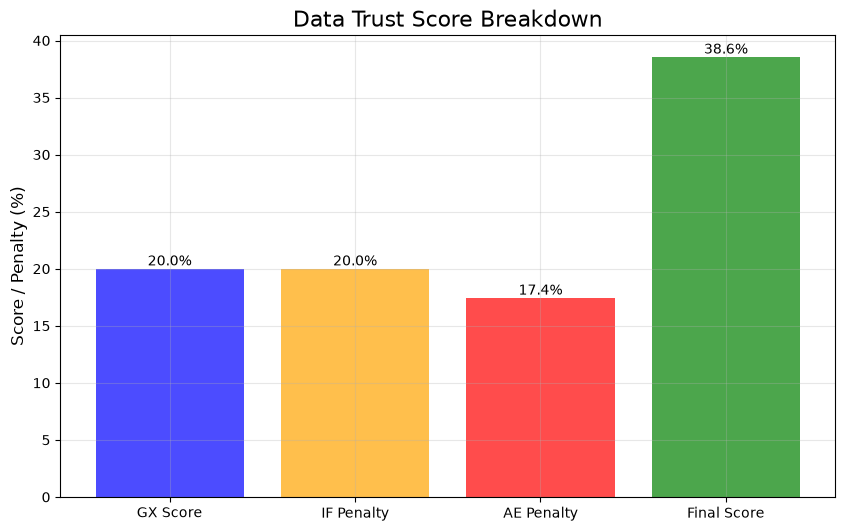

In [23]:
# ============================================
# Cell 5: Visualize the Score Breakdown
# ============================================

import matplotlib.pyplot as plt

# Data for the bar chart
categories = ['GX Score', 'IF Penalty', 'AE Penalty', 'Final Score']
values = [gx_score, if_penalty, ae_penalty, final_score]
colors = ['blue', 'orange', 'red', 'green']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.title('Data Trust Score Breakdown', fontsize=16)
plt.ylabel('Score / Penalty (%)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom')

plt.show()